# Исправление метаданных датасета
На странице датасета([ссылка](https://www.kaggle.com/datasets/humansintheloop/semantic-segmentation-of-aerial-imagery/data)) были указаны цветовые коды отличающиеся от тех, что были указаны в файле `classes.json`, поэтому был проведён анализ, в результате которого было установлено, что коды указанные на странице были истинными.

Приведенный ниже код перезаписывает файл `classes.json`, сохраняя в него правильные сопоставления классов и цветов, которые были определены путем анализа самих файлов масок. Это необходимо для корректной работы с данными и правильного обучения моделей.

In [1]:
import json

correct_classes_info = {
    "classes": [
        {"title": "Building", "color": "#3C1098"},
        {"title": "Land (unpaved area)", "color": "#8429F6"},
        {"title": "Road", "color": "#6EC1E4"},
        {"title": "Vegetation", "color": "#FEDD3A"},
        {"title": "Water", "color": "#E2A929"},
        {"title": "Unlabeled", "color": "#9B9B9B"}
    ],
    "tags": []
}

# Путь к файлу classes.json
classes_json_path = 'dataset/Semantic segmentation dataset/classes.json'

# Перезаписываем файл с корректными данными
with open(classes_json_path, 'w') as f:
    json.dump(correct_classes_info, f, indent=4)

print(f"Файл '{classes_json_path}' был успешно обновлен корректными данными.")

Файл 'dataset/Semantic segmentation dataset/classes.json' был успешно обновлен корректными данными.


In [2]:
# Установка необходимых библиотек
%pip install torch torchvision segmentation-models-pytorch albumentations Pillow numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


## 1. Импорт Библиотек

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import random

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

import albumentations as A
import segmentation_models_pytorch as smp

/home/denis/Study/CSP/CPS-CV/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Структура датасета и формирование списка путей к изображениям и маскам

Датасет организован в виде набора тайлов (Tile 1 – Tile 8).  
Каждый тайл содержит:
- папку `images` с исходными изображениями
- папку `masks` с размеченными масками

Маски представлены в формате RGB, где каждому классу соответствует определённый цвет.

В датасете изображения и маски находятся в отдельных папках, поэтому важно:
- отсортировать файлы
- сопоставить изображения и маски по порядку

In [4]:
DATA_DIR = 'dataset/Semantic segmentation dataset/'

IMAGE_DIRS = [os.path.join(DATA_DIR, f'Tile {i}/images') for i in range(1, 9)]
MASK_DIRS = [os.path.join(DATA_DIR, f'Tile {i}/masks') for i in range(1, 9)]

CLASS_RGB_VALUES = [
    [60, 16, 152],
    [132, 41, 246],
    [110, 193, 228],
    [254, 221, 58],
    [226, 169, 41],
    [155, 155, 155]
]

CLASS_NAMES = ["Building", "Land", "Road", "Vegetation", "Water", "Unlabeled"]

all_image_paths = []
all_mask_paths = []

for img_dir, mask_dir in zip(IMAGE_DIRS, MASK_DIRS):
    images = sorted([f for f in os.listdir(img_dir) if f.endswith('.jpg')])
    masks = sorted([f for f in os.listdir(mask_dir) if f.endswith('.png')])
    
    for img, mask in zip(images, masks):
        all_image_paths.append(os.path.join(img_dir, img))
        all_mask_paths.append(os.path.join(mask_dir, mask))

print(f"Всего изображений: {len(all_image_paths)}")
print(f"Всего масок: {len(all_mask_paths)}")

Всего изображений: 72
Всего масок: 72


## Разделение данных на обучающую, валидационную и тестовую выборки

Для корректной оценки качества модели датасет был разделён на три части:
- обучающая выборка (train) — используется для обучения модели
- валидационная выборка (validation) — используется для подбора гиперпараметров
- тестовая выборка (test) — используется для финальной оценки качества модели

Соотношение:
- 60% — обучение
- 20% — валидация
- 20% — тест

In [5]:
train_img, test_img, train_mask, test_mask = train_test_split(
    all_image_paths, all_mask_paths,
    test_size=0.2,
    random_state=42
)

train_img, val_img, train_mask, val_mask = train_test_split(
    train_img, train_mask,
    test_size=0.25,  # 0.25 * 0.8 = 0.2
    random_state=42
)

num_epochs = 20

print(f"Train: {len(train_img)}")
print(f"Validation: {len(val_img)}")
print(f"Test: {len(test_img)}")

Train: 42
Validation: 15
Test: 15


## Реализация класса Dataset

Для работы с данными реализуется собственный класс Dataset.

Основные задачи:
- загрузка изображений и масок
- преобразование RGB-масок в карту классов (индексы классов)
- применение аугментаций
- подготовка данных к подаче в модель

Особенность датасета:
маски представлены в формате RGB, поэтому требуется преобразование каждого цвета в индекс соответствующего класса.

In [6]:
class AerialDataset(Dataset):
    def __init__(self, image_paths, mask_paths, class_rgb_values, augmentation=None, preprocessing=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.class_rgb_values = class_rgb_values
        self.augmentation = augmentation
        self.preprocessing = preprocessing

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("RGB"))

        semantic_map = np.full(mask.shape[:2], 255, dtype=np.uint8)

        for i, rgb in enumerate(self.class_rgb_values):
            matches = np.all(mask == rgb, axis=-1)
            semantic_map[matches] = i

        if self.augmentation:
            sample = self.augmentation(image=image, mask=semantic_map)
            image, semantic_map = sample['image'], sample['mask']

        if self.preprocessing:
            sample = self.preprocessing(image=image, mask=semantic_map)
            image, semantic_map = sample['image'], sample['mask']

        return image, semantic_map

In [7]:
dataset_test = AerialDataset(train_img, train_mask, CLASS_RGB_VALUES)
img, mask = dataset_test[0]

print(img.shape)
print(mask.shape)
print(np.unique(mask))

(2062, 1816, 3)
(2062, 1816)
[0 1 2 3 4 5]


## Аугментации и предобработка данных

Для повышения обобщающей способности модели применяются аугментации:
- случайные повороты
- отражения по горизонтали и вертикали
- изменение ориентации изображения

Также выполняется:
- приведение изображений к фиксированному размеру
- нормализация входных данных под предобученную модель
- преобразование данных в тензоры PyTorch

In [8]:
def get_training_augmentation():
    return A.Compose([
        A.Resize(256, 256),

        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),

        A.RandomBrightnessContrast(p=0.3),
        A.ShiftScaleRotate(
            shift_limit=0.1,
            scale_limit=0.1,
            rotate_limit=15,
            p=0.3
        ),
    ])

def get_validation_augmentation():
    return A.Compose([
        A.Resize(256, 256)
    ])

def to_tensor(x, **kwargs):
    return x.transpose(2, 0, 1).astype('float32')

def mask_to_tensor(x, **kwargs):
    return x.astype('int64')

def get_preprocessing(preprocessing_fn):
    return A.Compose([
        A.Lambda(image=preprocessing_fn),
        A.Lambda(image=to_tensor, mask=mask_to_tensor),
    ])

## Формирование DataLoader

На данном этапе создаются загрузчики данных (DataLoader), которые обеспечивают:
- пакетную подачу данных в модель
- перемешивание обучающей выборки
- ускоренную загрузку данных

Также выполняется проверка корректности одного батча перед обучением модели.

In [9]:
ENCODER = 'resnet34'
ENCODER_WEIGHTS = 'imagenet'

preprocessing_fn = smp.encoders.get_preprocessing_fn(
    ENCODER,
    ENCODER_WEIGHTS
)

train_dataset = AerialDataset(
    train_img,
    train_mask,
    CLASS_RGB_VALUES,
    augmentation=get_training_augmentation(),
    preprocessing=get_preprocessing(preprocessing_fn)
)

valid_dataset = AerialDataset(
    val_img,
    val_mask,
    CLASS_RGB_VALUES,
    augmentation=get_validation_augmentation(),
    preprocessing=get_preprocessing(preprocessing_fn)
)

test_dataset = AerialDataset(
    test_img,
    test_mask,
    CLASS_RGB_VALUES,
    augmentation=get_validation_augmentation(),
    preprocessing=get_preprocessing(preprocessing_fn)
)

BATCH_SIZE = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=1, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

print("DataLoader'ы созданы")

DataLoader'ы созданы


/home/denis/Study/CSP/CPS-CV/.venv/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [10]:
images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

print("Unique mask values:", torch.unique(masks))

Images shape: torch.Size([4, 3, 256, 256])
Masks shape: torch.Size([4, 256, 256])
Unique mask values: tensor([0, 1, 2, 3, 4, 5])


### Выбор устройства, на котором производится обучение

In [11]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

Using device: cuda


### Общая функция обучения

In [12]:
def train_model(model, optimizer, scheduler, name, epochs=10):
    best_iou = 0.0

    for epoch in range(epochs):
        print(f"\n{name} - Эпоха {epoch+1}/{epochs}")

        model.train()
        train_loss = 0.0

        for images, masks in train_loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)
            loss = loss_fn(outputs, masks)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        model.eval()
        tp, fp, fn, tn = 0, 0, 0, 0

        with torch.no_grad():
            for images, masks in valid_loader:
                images = images.to(DEVICE)
                masks = masks.to(DEVICE)

                outputs = model(images)
                outputs = torch.argmax(outputs, dim=1)

                stats = smp.metrics.get_stats(
                    outputs,
                    masks,
                    mode="multiclass",
                    num_classes=len(CLASS_NAMES),
                    ignore_index=255
                )

                tp += stats[0]
                fp += stats[1]
                fn += stats[2]
                tn += stats[3]

        val_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")

        print(f"Train Loss: {avg_train_loss:.4f} | Val IoU: {val_iou:.4f}")

        scheduler.step(val_iou)

        if val_iou > best_iou:
            best_iou = val_iou
            torch.save(model.state_dict(), f"{name}_best.pth")
            print("Лучшая модель сохранена!")

    return best_iou

class_weights = torch.tensor([
    1.0,  # Building
    0.5,  # Land
    2.0,  # Road
    1.5,  # Vegetation
    1.0,  # Water
    0.5   # Unlabeled
]).to(DEVICE)

dice_loss = smp.losses.DiceLoss(mode="multiclass", ignore_index=255)
ce_loss = nn.CrossEntropyLoss(
    weight=class_weights,
    ignore_index=255
)

def loss_fn(pred, target):
    return 0.7 * dice_loss(pred, target) + 0.3 * ce_loss(pred, target)

##

In [13]:
baseline_model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    classes=len(CLASS_NAMES),
    activation=None,
).to(DEVICE)

optimizer_base = torch.optim.Adam(baseline_model.parameters(), lr=1e-4)

scheduler_base = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_base,
    mode="max",
    patience=2,
    factor=0.5
)

##

In [14]:
baseline_iou = train_model(
    baseline_model, 
    optimizer_base, 
    scheduler_base, 
    "Baseline", 
    epochs=num_epochs
)



Baseline - Эпоха 1/20
Train Loss: 1.2332 | Val IoU: 0.0590
Лучшая модель сохранена!

Baseline - Эпоха 2/20
Train Loss: 1.1565 | Val IoU: 0.0932
Лучшая модель сохранена!

Baseline - Эпоха 3/20
Train Loss: 1.0833 | Val IoU: 0.1445
Лучшая модель сохранена!

Baseline - Эпоха 4/20
Train Loss: 1.0276 | Val IoU: 0.2323
Лучшая модель сохранена!

Baseline - Эпоха 5/20
Train Loss: 1.0338 | Val IoU: 0.3041
Лучшая модель сохранена!

Baseline - Эпоха 6/20
Train Loss: 0.9679 | Val IoU: 0.3720
Лучшая модель сохранена!

Baseline - Эпоха 7/20
Train Loss: 0.9184 | Val IoU: 0.4126
Лучшая модель сохранена!

Baseline - Эпоха 8/20
Train Loss: 0.9362 | Val IoU: 0.4369
Лучшая модель сохранена!

Baseline - Эпоха 9/20
Train Loss: 0.9008 | Val IoU: 0.4605
Лучшая модель сохранена!

Baseline - Эпоха 10/20
Train Loss: 0.8377 | Val IoU: 0.4759
Лучшая модель сохранена!

Baseline - Эпоха 11/20
Train Loss: 0.8324 | Val IoU: 0.5046
Лучшая модель сохранена!

Baseline - Эпоха 12/20
Train Loss: 0.8071 | Val IoU: 0.4922

B

## Создание улучшенного бейзлайна

In [15]:
improved_model = smp.Unet(
    encoder_name="se_resnext50_32x4d",
    encoder_weights="imagenet",
    classes=len(CLASS_NAMES),
    activation=None,
).to(DEVICE)

optimizer_imp = torch.optim.Adam(improved_model.parameters(), lr=1e-4)

scheduler_imp = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_imp,
    mode="max",
    patience=2,
    factor=0.5
)

## Обучение улучшенного бейзлайна

In [16]:
improved_iou = train_model(
    improved_model, 
    optimizer_imp, 
    scheduler_imp, 
    "Improved", 
    epochs=num_epochs
)


Improved - Эпоха 1/20
Train Loss: 1.1840 | Val IoU: 0.0751
Лучшая модель сохранена!

Improved - Эпоха 2/20
Train Loss: 1.1137 | Val IoU: 0.2036
Лучшая модель сохранена!

Improved - Эпоха 3/20
Train Loss: 1.0484 | Val IoU: 0.3131
Лучшая модель сохранена!

Improved - Эпоха 4/20
Train Loss: 1.0088 | Val IoU: 0.3637
Лучшая модель сохранена!

Improved - Эпоха 5/20
Train Loss: 0.9722 | Val IoU: 0.4214
Лучшая модель сохранена!

Improved - Эпоха 6/20
Train Loss: 0.9301 | Val IoU: 0.4530
Лучшая модель сохранена!

Improved - Эпоха 7/20
Train Loss: 0.9000 | Val IoU: 0.4692
Лучшая модель сохранена!

Improved - Эпоха 8/20
Train Loss: 0.8725 | Val IoU: 0.4793
Лучшая модель сохранена!

Improved - Эпоха 9/20
Train Loss: 0.8214 | Val IoU: 0.5305
Лучшая модель сохранена!

Improved - Эпоха 10/20
Train Loss: 0.8040 | Val IoU: 0.5524
Лучшая модель сохранена!

Improved - Эпоха 11/20
Train Loss: 0.7760 | Val IoU: 0.5636
Лучшая модель сохранена!

Improved - Эпоха 12/20
Train Loss: 0.7526 | Val IoU: 0.5801
Лу

##

In [17]:
print("\n==================== Сравнение ====================")
print(f"Базовый UNet IoU  : {baseline_iou:.4f}")
print(f"Улучшенный UNet IoU  : {improved_iou:.4f}")
print(f"Улучшение       : {improved_iou - baseline_iou:.4f}")


==================== Сравнение ====================
Базовый UNet IoU  : 0.5835
Улучшенный UNet IoU  : 0.6089
Улучшение       : 0.0254


## Собственная реализация модели сегментации

Для выполнения требования задания была реализована собственная архитектура U-Net без использования готовых реализаций библиотек.

Модель состоит из:
- сверточных блоков
- операций downsampling (MaxPool)
- операций upsampling (ConvTranspose2d)
- skip-connections

Данная модель используется для сравнения с предобученными архитектурами.

In [18]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class MyUNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.down1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(64, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        x1 = self.down1(x)
        x2 = self.down2(self.pool1(x1))
        x3 = self.bottleneck(self.pool2(x2))

        x = self.up2(x3)
        x = torch.cat([x, x2], dim=1)
        x = self.conv2(x)

        x = self.up1(x)
        x = torch.cat([x, x1], dim=1)
        x = self.conv1(x)

        return self.out(x)

## Создание и обучение собственной модели

Собственная реализация U-Net обучается на тех же данных и с теми же гиперпараметрами,
что и базовая и улучшенная модели, для обеспечения корректного сравнения.

In [19]:
own_model = MyUNet(num_classes=len(CLASS_NAMES)).to(DEVICE)

optimizer_own = torch.optim.AdamW(
    own_model.parameters(), 
    lr=3e-5, 
    weight_decay=1e-4
)

scheduler_own = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_own,
    mode="max",
    patience=2,
    factor=0.5
)

## Обучение собственной модели

In [20]:
own_iou = train_model(
    own_model, 
    optimizer_own, 
    scheduler_own, 
    "MyUNet", 
    epochs=10
)


MyUNet - Эпоха 1/10
Train Loss: 1.1488 | Val IoU: 0.1189
Лучшая модель сохранена!

MyUNet - Эпоха 2/10
Train Loss: 1.1475 | Val IoU: 0.1228
Лучшая модель сохранена!

MyUNet - Эпоха 3/10
Train Loss: 1.1353 | Val IoU: 0.1251
Лучшая модель сохранена!

MyUNet - Эпоха 4/10
Train Loss: 1.1438 | Val IoU: 0.1327
Лучшая модель сохранена!

MyUNet - Эпоха 5/10
Train Loss: 1.1308 | Val IoU: 0.2861
Лучшая модель сохранена!

MyUNet - Эпоха 6/10
Train Loss: 1.1369 | Val IoU: 0.3695
Лучшая модель сохранена!

MyUNet - Эпоха 7/10
Train Loss: 1.1300 | Val IoU: 0.4245
Лучшая модель сохранена!

MyUNet - Эпоха 8/10
Train Loss: 1.1048 | Val IoU: 0.4592
Лучшая модель сохранена!

MyUNet - Эпоха 9/10
Train Loss: 1.0940 | Val IoU: 0.4844
Лучшая модель сохранена!

MyUNet - Эпоха 10/10
Train Loss: 1.0474 | Val IoU: 0.4451


In [21]:
print("\n==================== Финальное сравнение ====================")

print(f"Базовый UNet       : {baseline_iou:.4f}")
print(f"Улчушенный UNet       : {improved_iou:.4f}")
print(f"Мой UNet   : {own_iou:.4f}")

print("\n-------------------- Улучшение --------------------")
print(f"Улчушенный vs Базовый : {improved_iou - baseline_iou:.4f}")
print(f"Мой UNet vs Базовый   : {own_iou - baseline_iou:.4f}")


==================== Финальное сравнение ====================
Базовый UNet       : 0.5835
Улчушенный UNet       : 0.6089
Мой UNet   : 0.4844

-------------------- Улучшение --------------------
Улчушенный vs Базовый : 0.0254
Мой UNet vs Базовый   : -0.0991


## Функция визуализации результатов

Для удобного сравнения моделей реализована универсальная функция визуализации,
показывающая:
- исходное изображение
- ground truth маску
- предсказание модели

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import random

def decode_mask(mask, colors):
    h, w = mask.shape
    out = np.zeros((h, w, 3), dtype=np.uint8)

    for i, c in enumerate(colors):
        out[mask == i] = c

    out[mask == 255] = [0, 0, 0]
    return out


def to_tensor_image(image):
    """
    Универсально приводит image к torch tensor CHW
    """
    if isinstance(image, torch.Tensor):
        return image

    image = np.array(image)


    if image.shape[-1] == 3:
        image = torch.from_numpy(image).permute(2, 0, 1)
    else:
        image = torch.from_numpy(image)
    return image


def visualize_model(model, dataset, title="Model"):
    model.eval()

    idx = random.randint(0, len(dataset) - 1)
    image, mask = dataset[idx]

    image_tensor = to_tensor_image(image)
    img = image_tensor.unsqueeze(0).float().to(DEVICE)

    with torch.no_grad():
        pred = model(img)
        pred = torch.argmax(pred, dim=1).squeeze(0).cpu().numpy()

    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()

    gt_rgb = decode_mask(mask, CLASS_RGB_VALUES)
    pred_rgb = decode_mask(pred, CLASS_RGB_VALUES)

    img_vis = image_tensor.permute(1, 2, 0).cpu().numpy()
    img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min() + 1e-8)

    plt.figure(figsize=(15, 5))
    plt.suptitle(title)

    plt.subplot(1, 3, 1)
    plt.title("Image")
    plt.imshow(img_vis)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(gt_rgb)
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(pred_rgb)
    plt.axis("off")

    plt.show()

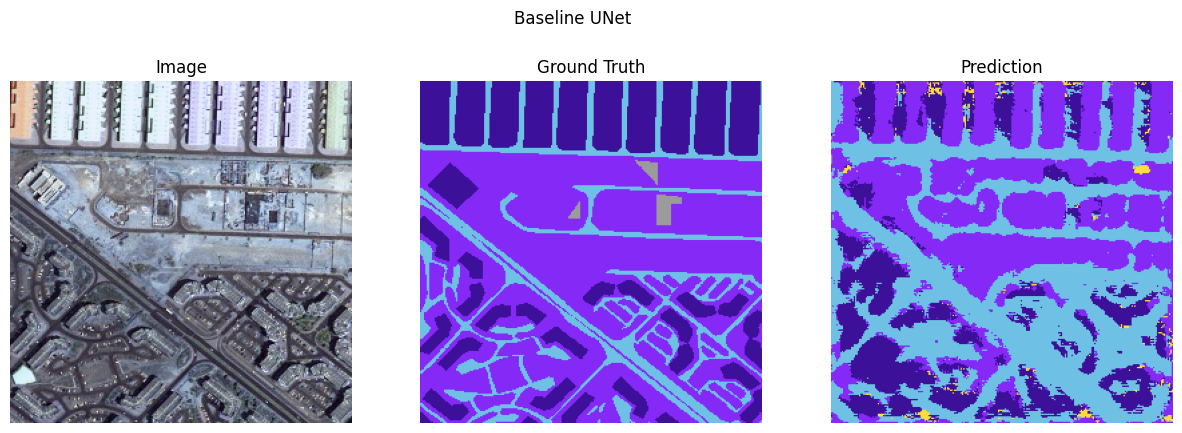

In [52]:
visualize_model(baseline_model, test_dataset, "Baseline UNet")

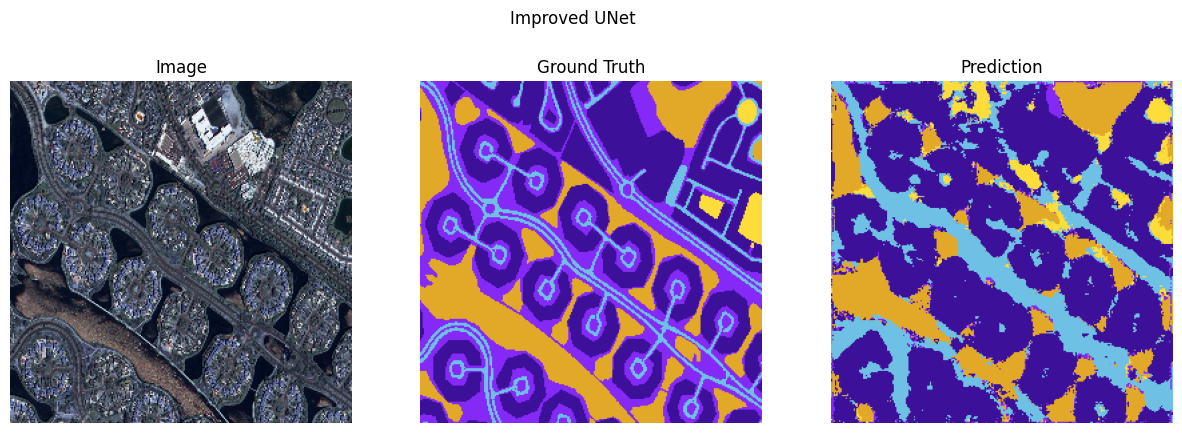

In [41]:
visualize_model(improved_model, test_dataset, "Improved UNet")

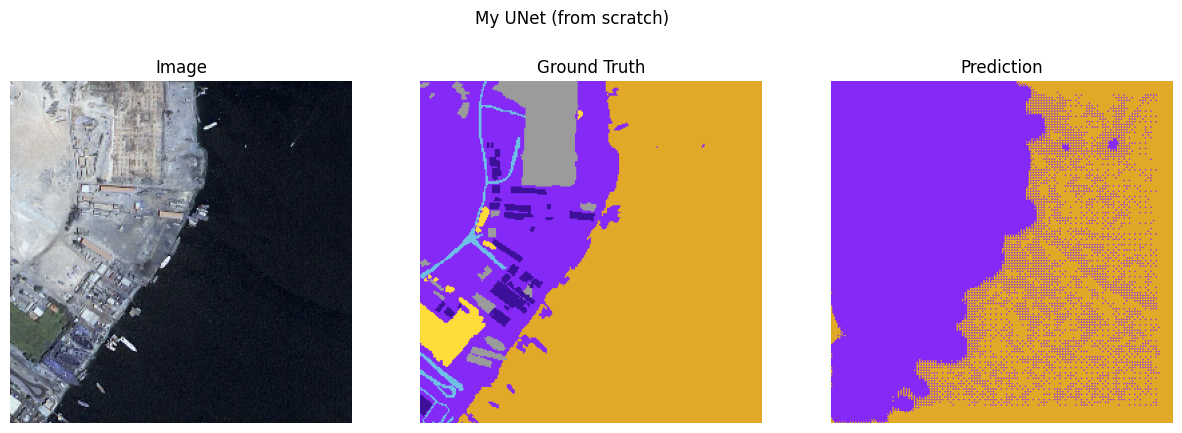

In [39]:
visualize_model(own_model, test_dataset, "My UNet (from scratch)")

## Детальное сравнение всех моделей

In [26]:
def evaluate_model(model, loader):
    model.eval()

    tp, fp, fn, tn = 0, 0, 0, 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            outputs = model(images)
            outputs = torch.argmax(outputs, dim=1)

            stats = smp.metrics.get_stats(
                outputs,
                masks,
                mode="multiclass",
                num_classes=len(CLASS_NAMES),
                ignore_index=255
            )

            tp += stats[0]
            fp += stats[1]
            fn += stats[2]
            tn += stats[3]

    iou_micro = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")
    iou_per_class = smp.metrics.iou_score(tp, fp, fn, tn, reduction=None)

    return iou_micro, iou_per_class

In [27]:
baseline_iou, baseline_cls = evaluate_model(baseline_model, test_loader)
improved_iou, improved_cls = evaluate_model(improved_model, test_loader)
own_iou, own_cls = evaluate_model(own_model, test_loader)

In [28]:
print("\n================ СРАВНЕНИЕ МОДЕЛЕЙ =================\n")

print(f"{'Модель':<25} {'IoU (средний)':<15}")
print("-"*45)

print(f"{'Базовая UNet':<25} {baseline_iou:.4f}")
print(f"{'Улучшенная UNet':<25} {improved_iou:.4f}")
print(f"{'Собственная UNet':<25} {own_iou:.4f}")

print("\n---------------- Улучшение ----------------")

print(f"Улучшенная vs Базовая: {improved_iou - baseline_iou:.4f}")
print(f"Собственная vs Базовая: {own_iou - baseline_iou:.4f}")


================ СРАВНЕНИЕ МОДЕЛЕЙ =================

Модель                    IoU (средний)  
---------------------------------------------
Базовая UNet              0.5472
Улучшенная UNet           0.5697
Собственная UNet          0.3804

---------------- Улучшение ----------------
Улучшенная vs Базовая: 0.0225
Собственная vs Базовая: -0.1667


In [29]:
def print_class_iou_ru(name, iou):
    print(f"\n{name} — IoU по классам:")

    if torch.is_tensor(iou):
        iou = iou.detach().cpu().numpy()

    iou = np.array(iou).reshape(-1)

    for i in range(len(CLASS_NAMES)):
        value = float(iou[i])
        print(f"  {CLASS_NAMES[i]:<15}: {value:.4f}")


print_class_iou_ru("Базовая модель", baseline_cls)
print_class_iou_ru("Улучшенная модель", improved_cls)
print_class_iou_ru("Собственная модель", own_cls)


Базовая модель — IoU по классам:
  Building       : 0.4725
  Land           : 0.5796
  Road           : 0.3028
  Vegetation     : 0.6222
  Water          : 0.7951
  Unlabeled      : 0.0038

Улучшенная модель — IoU по классам:
  Building       : 0.5511
  Land           : 0.5638
  Road           : 0.3281
  Vegetation     : 0.7351
  Water          : 0.8132
  Unlabeled      : 0.0014

Собственная модель — IoU по классам:
  Building       : 0.0012
  Land           : 0.5226
  Road           : 0.0000
  Vegetation     : 0.0000
  Water          : 0.5055
  Unlabeled      : 0.0000
